In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import importlib


In [ ]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)

In [ ]:
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"

In [23]:
# Add condition from filename
def get_condition(filename):
    if filename.startswith("BLRI"):
        return "Baseline"
    elif filename.startswith("RI1"):
        return "RI1 (Positive)"
    elif filename.startswith("RI2"):
        return "RI2 (Negative)"
    else:
        return "Unknown"

# Add subject from filename
def get_subject(filename):
    parts = filename.split('_')
    return parts[1] + "_" + parts[2]  # e.g., "s3_6"

df["Condition"] = df["file"].apply(get_condition)
df["Subject"] = df["file"].apply(get_subject)


In [5]:
RI1_3_6_h5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_h5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")

In [6]:
RI1_3_6_h5_boris.head() 

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
0,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,anogenital sniffing,Not defined,STATE,8.862,9.448,0.586,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,257,274.0,NaN,NaN,NaN,NaN
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,facial sniffing,Not defined,STATE,11.966,13.000,1.034,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,347,377.0,NaN,NaN,NaN,NaN
2,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,12.069,12.862,0.793,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,350,373.0,NaN,NaN,NaN,NaN
3,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,body sniffing,Not defined,STATE,13.276,13.448,0.172,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,385,390.0,NaN,NaN,NaN,NaN
4,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,anogenital sniffing,Not defined,STATE,14.483,16.690,2.207,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,420,484.0,NaN,NaN,NaN,NaN


### Filtering out social_agent so only subject behaviors plotted

In [7]:
# taking out all rows with subject=social_agent
RI1_3_6_h5_boris = RI1_3_6_h5_boris[RI1_3_6_h5_boris['Subject'] != 'social_agent']
RI2_3_6_h5_boris = RI2_3_6_h5_boris[RI2_3_6_h5_boris['Subject'] != 'social_agent']

In [8]:
RI1_3_6_h5_boris.head()

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,facial sniffing,Not defined,STATE,11.966,13.000,1.034,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,347,377.0,NaN,NaN,NaN,NaN
3,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,body sniffing,Not defined,STATE,13.276,13.448,0.172,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,385,390.0,NaN,NaN,NaN,NaN
4,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,anogenital sniffing,Not defined,STATE,14.483,16.690,2.207,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,420,484.0,NaN,NaN,NaN,NaN
5,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,anogenital sniffing,Not defined,STATE,19.069,19.483,0.414,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,553,565.0,NaN,NaN,NaN,NaN
6,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,anogenital sniffing,Not defined,STATE,21.379,21.724,0.345,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,620,630.0,NaN,NaN,NaN,NaN


### Function to quickly get read and filter resp data and create Rsp_Kit object with behavior

In [9]:
def get_kit(h5_file, target_rate=100, behavior_data=None):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    return rsp_cleaned


In [10]:
def plot_resp_one_by_one(resp_signal, behavior_df, sampling_rate=100):
    behavior_df = behavior_df[behavior_df['Duration (s)'] >= 1.0]

    pre_time = 1.0
    post_time = 1.0

    for _, row in behavior_df.iterrows():
        start_time = row['Start (s)']
        duration = row['Duration (s)']
        behavior = row['Behavior']

        start_idx = int((start_time - pre_time) * sampling_rate)
        end_idx = int((start_time + duration + post_time) * sampling_rate)

        if start_idx < 0 or end_idx > len(resp_signal):
            print(f"Skipping '{behavior}' at {start_time:.2f}s — out of bounds")
            continue

        segment = resp_signal[start_idx:end_idx]
        times = np.linspace(-pre_time, duration + post_time, len(segment))

        plt.figure(figsize=(8, 4))
        plt.plot(times, segment, color='black')
        plt.axvspan(0, duration, color='gray', alpha=0.4)

        plt.title(f"{behavior} ({start_time:.2f}s)", fontsize=22)
        plt.ylabel("Resp", fontsize=22)
        plt.xlabel("Time (s)", fontsize=22)

        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)

        plt.grid(False)
        plt.tight_layout()
        plt.show()


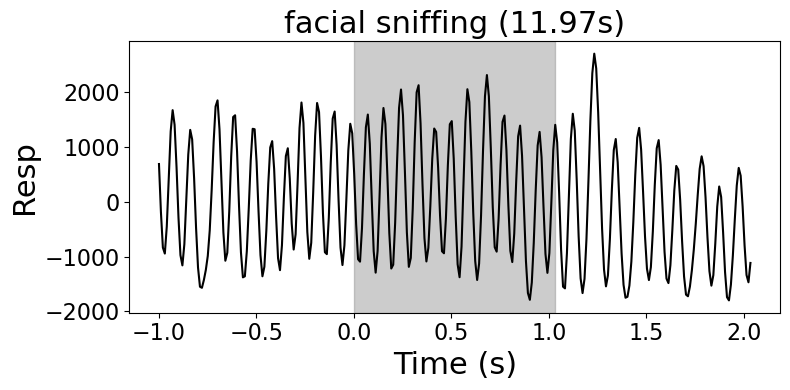

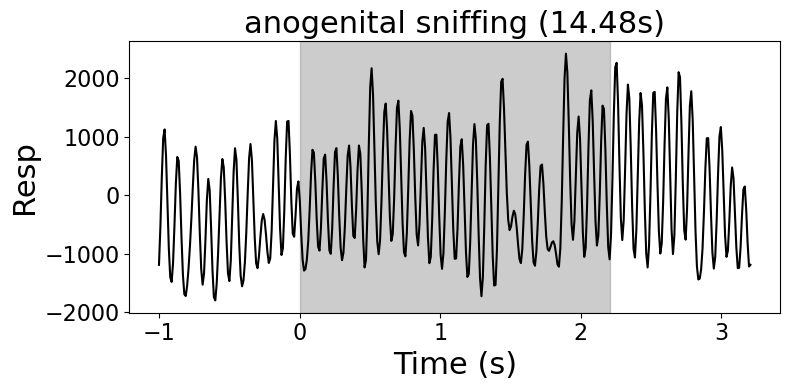

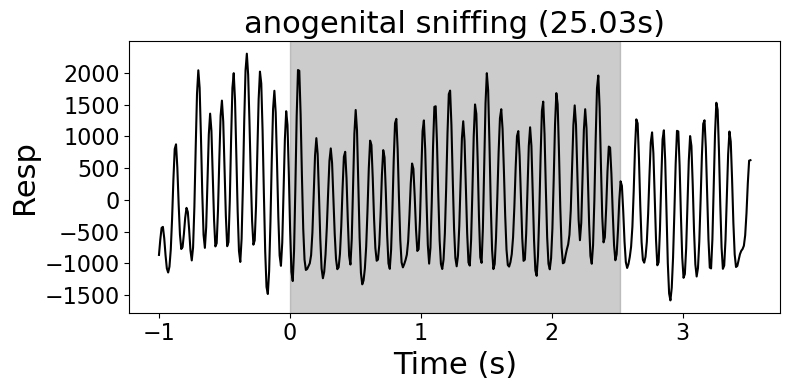

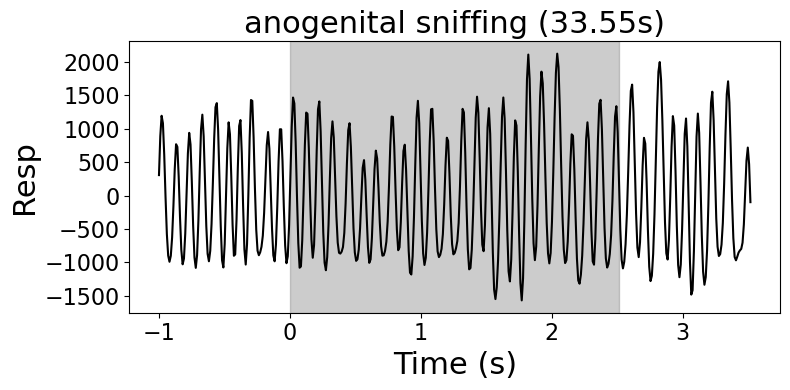

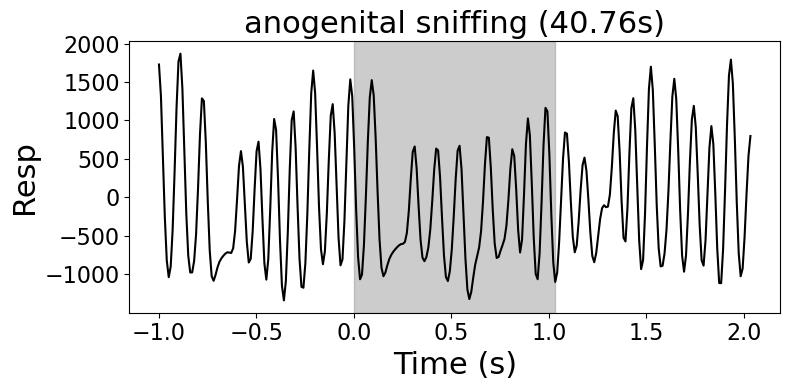

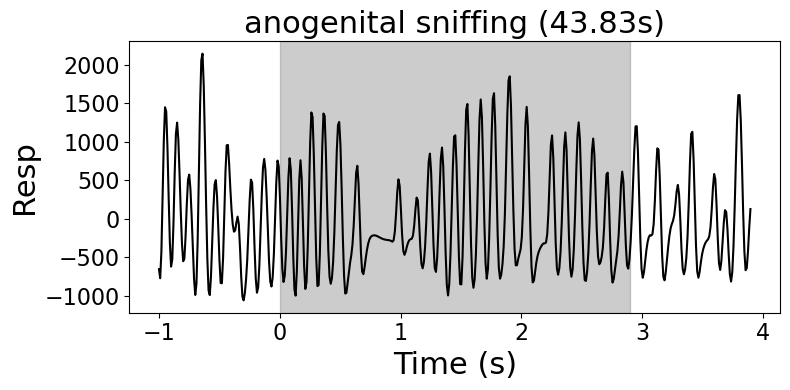

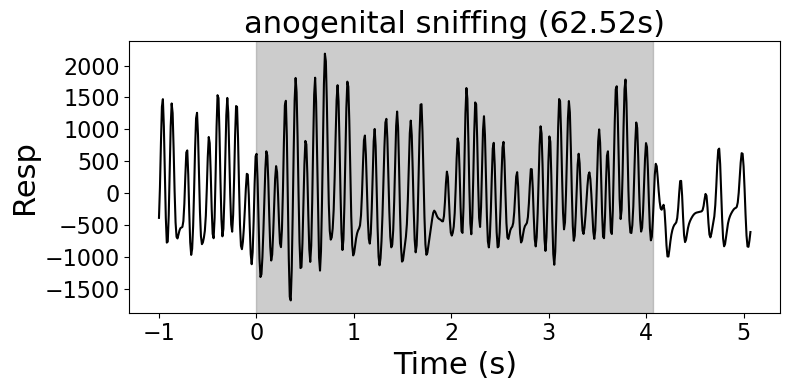

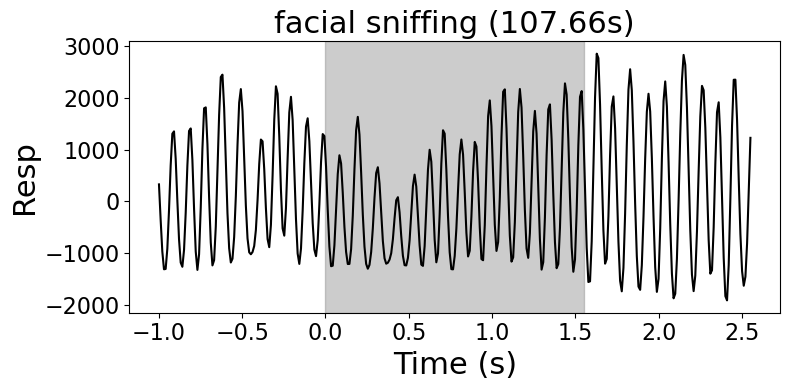

In [11]:
# Step 1: Load respiration trace
resp_trace = get_kit(RI1_3_6_h5_path, target_rate=100)

# Step 2: Run plotting function
plot_resp_one_by_one(resp_trace, RI1_3_6_h5_boris, sampling_rate=100)


In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk

# Set display options for pandas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

# === File paths ===
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
RI2_3_6_boris_path = r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv"

# === Load BORIS file, filter out social_agent rows ===
RI2_3_6_boris = pd.read_csv(RI2_3_6_boris_path)
RI2_3_6_boris = RI2_3_6_boris[RI2_3_6_boris['Subject'] != 'social_agent']

# === Load and preprocess respiration ===
def get_kit(h5_file, target_rate=100):
    with h5py.File(h5_file, 'r') as f:
        resp = f['resp'][:].flatten()
        ekg_meta = dict(f['ekg_metadata'].attrs)

    fs = len(resp) / ekg_meta['duration_sec']

    # Low-pass filter before downsampling
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Final cleaning
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    return rsp_cleaned

# === Plotting ===
def plot_resp_around_behaviors(resp_signal, behavior_df, sampling_rate=100):
    behavior_df = behavior_df[behavior_df['Duration (s)'] >= .500]

    pre_time = 1.0
    post_time = 1.0

    num_behaviors = len(behavior_df)
    fig, axs = plt.subplots(num_behaviors, 1, figsize=(10, 2 * num_behaviors), sharex=False)

    if num_behaviors == 1:
        axs = [axs]

    for i, (_, row) in enumerate(behavior_df.iterrows()):
        start_time = row['Start (s)']
        duration = row['Duration (s)']
        behavior = row['Behavior']

        start_idx = int((start_time - pre_time) * sampling_rate)
        end_idx = int((start_time + duration + post_time) * sampling_rate)

        if start_idx < 0 or end_idx > len(resp_signal):
            print(f"Skipping '{behavior}' at {start_time:.2f}s — out of bounds")
            continue

        segment = resp_signal[start_idx:end_idx]
        times = np.linspace(-pre_time, duration + post_time, len(segment))

        axs[i].plot(times, segment, color='black')
        axs[i].axvspan(0, duration, color='gray', alpha=0.4)

        # Title and axis labels with fontsize 22
        axs[i].set_title(f"{behavior} ({start_time:.2f}s)", fontsize=22)
        axs[i].set_ylabel("Resp", fontsize=22)

        # Remove grid
        axs[i].grid(False)

        # Set tick label fontsize to 16
        axs[i].tick_params(axis='both', which='major', labelsize=16)

    axs[-1].set_xlabel("Time (s)", fontsize=22)
    axs[-1].tick_params(axis='x', which='major', labelsize=16)

    plt.tight_layout()
    plt.show()



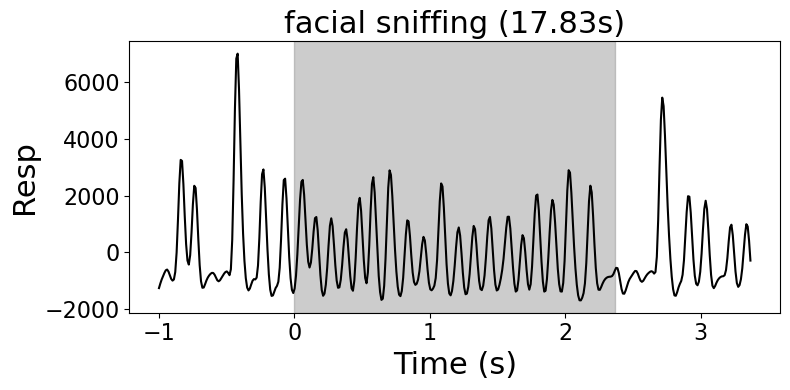

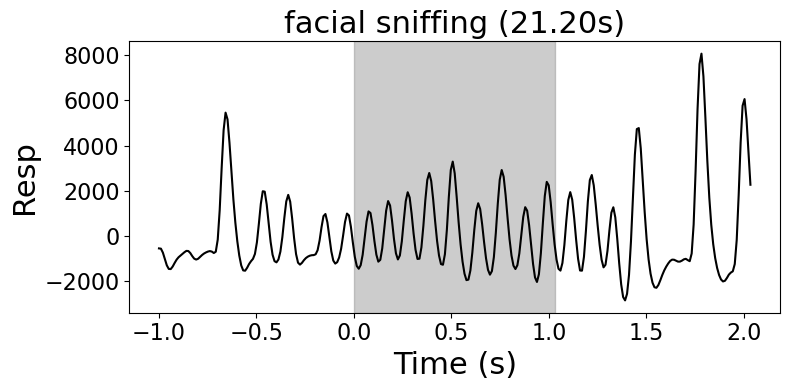

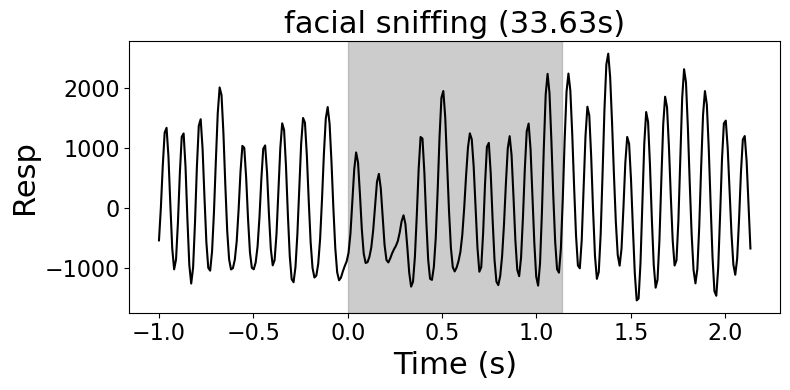

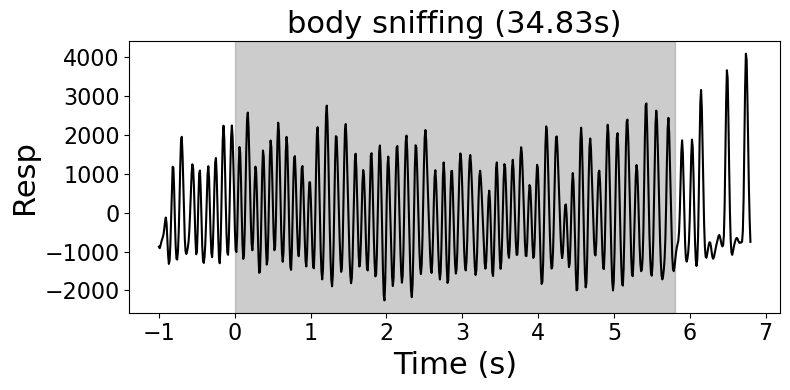

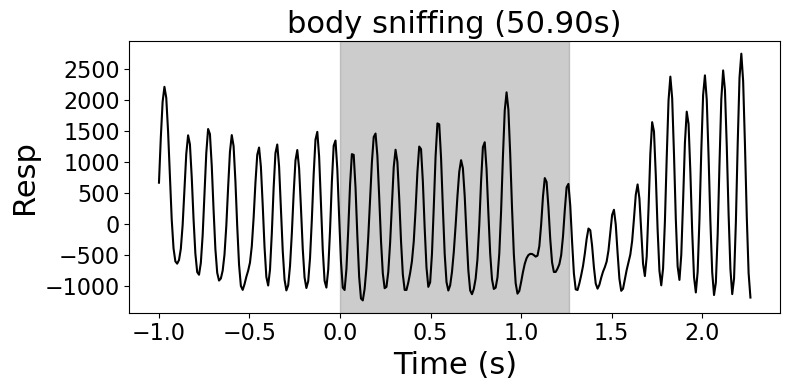

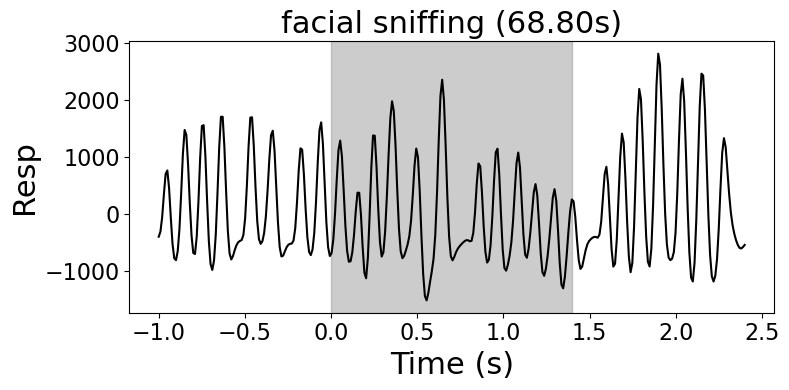

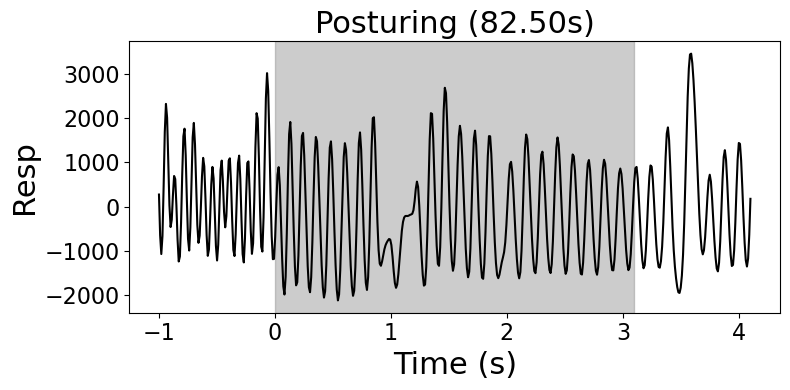

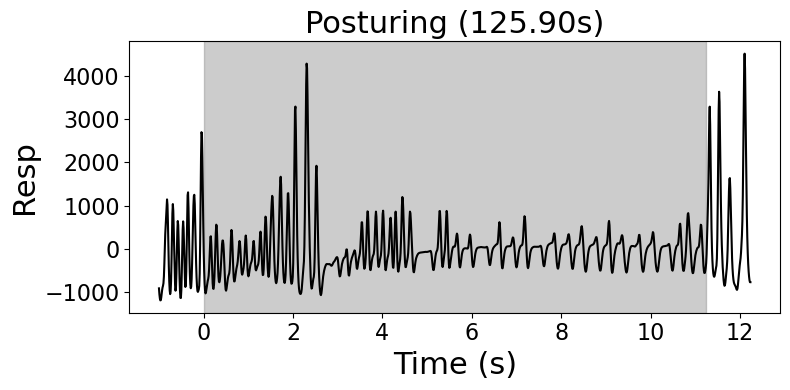

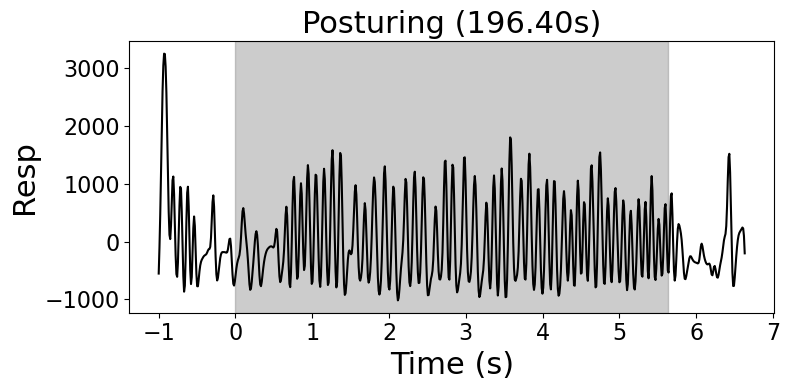

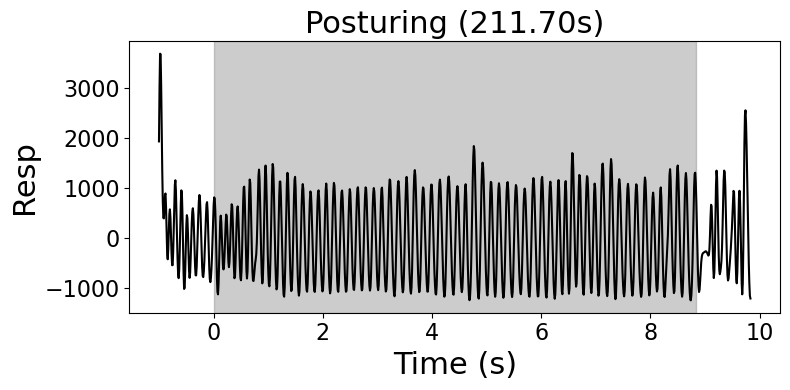

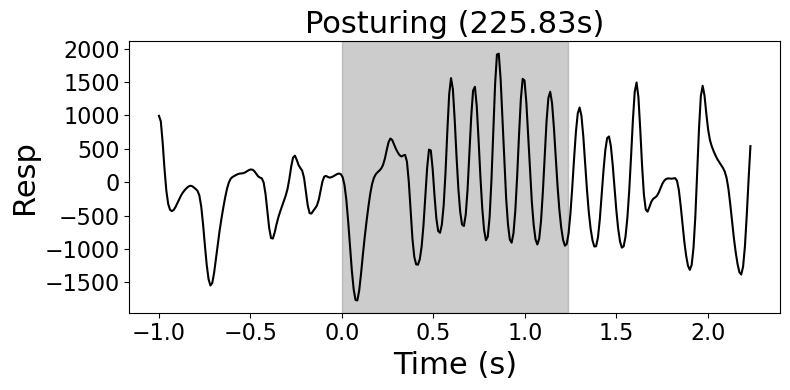

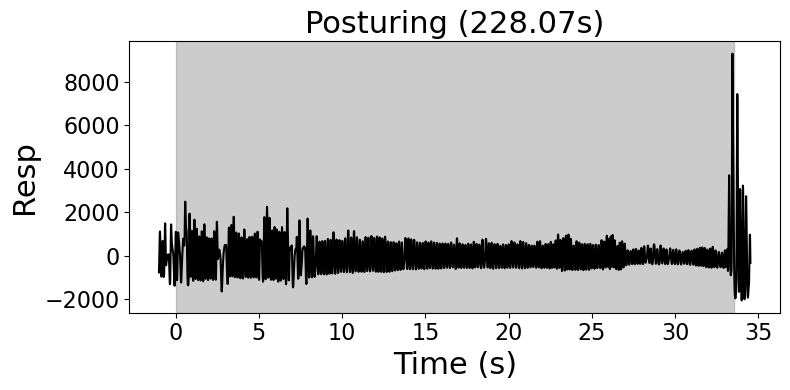

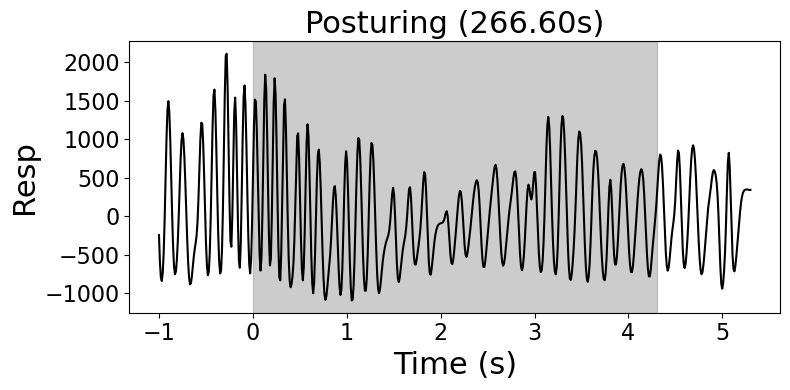

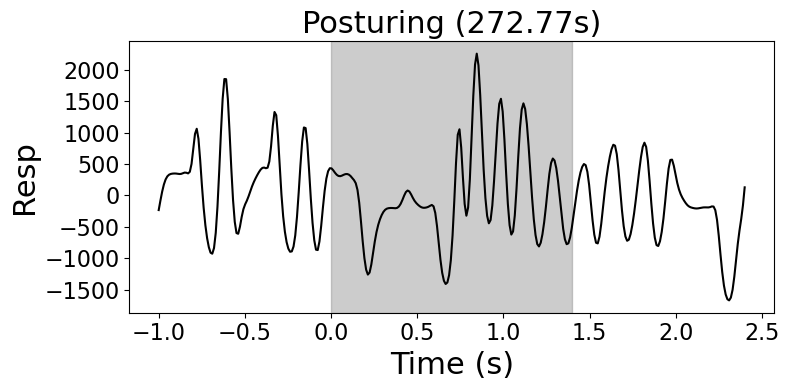

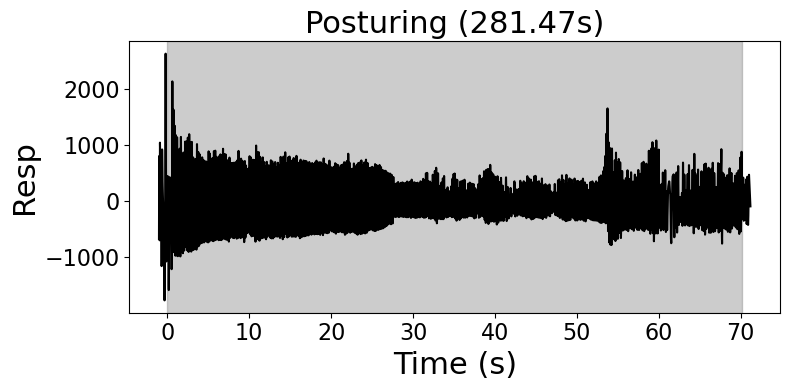

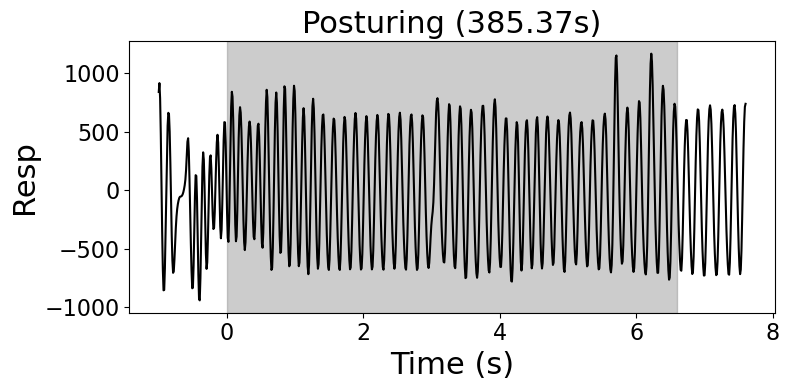

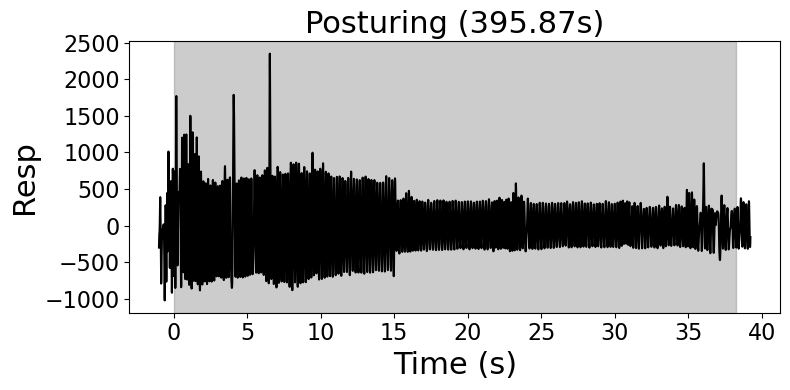

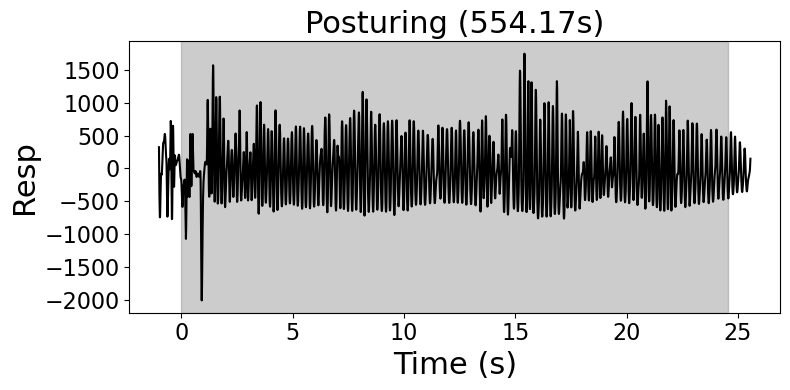

In [58]:
resp_trace_ri2 = get_kit(RI2_3_6_h5_path, target_rate=100)
plot_resp_one_by_one(resp_trace_ri2, RI2_3_6_boris, sampling_rate=100)
